## Run the shapefile on a gerrychain.

In [1]:
import warnings
from gerrychain import Graph, Partition, proposals, updaters, constraints, accept, MarkovChain, Election
from gerrychain.updaters import cut_edges, Tally
from gerrychain.proposals import recom
from gerrychain.accept import always_accept
from gerrychain.metrics import efficiency_gap
import geopandas as gpd
import matplotlib.pyplot as plt
import networkx as nx
from functools import partial
from gerrychain.tree import bipartition_tree
import pandas as pd


In [2]:
RI_graph = Graph.from_file("./FinalShapeFiles/RI.shp")

# CITE: https://networkx.org/documentation/stable/tutorial.html
RI_df = gpd.read_file("./FinalShapeFiles/RI.shp")



/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/gerrychain/graph/graph.py:406: UserWarning: Found islands (degree-0 nodes). Indices of islands: {91}
  warnings.warn(


In [3]:
# Check if the dual graph is connected
is_contig = nx.is_connected(RI_graph)
print(f"Dual graph is connected or not: {is_contig}")

Dual graph is connected or not: False


Make the dual graph connected by connecting the isolated Island.

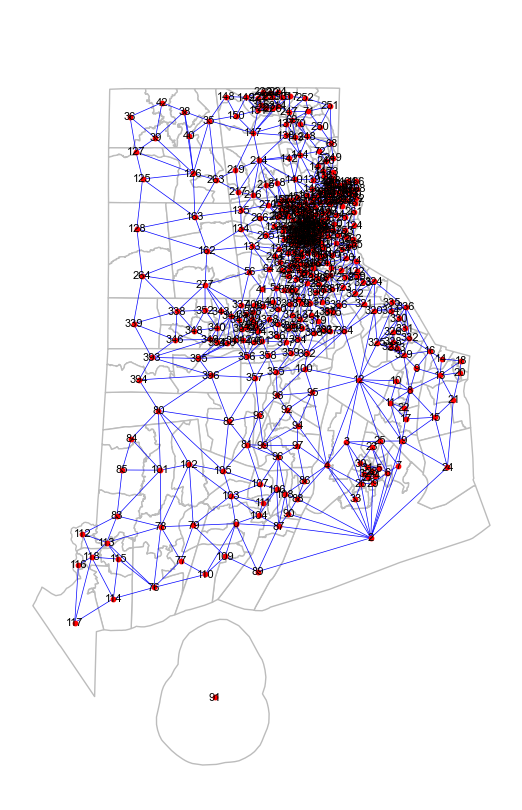

In [4]:
#plot graph
fig, ax = plt.subplots(figsize=(10, 10))

RI_df.plot(ax=ax, color="white", edgecolor="#bcbcbc")

# get the centriod of each place
pos = {node: (RI_df.geometry[node].centroid.x, RI_df.geometry[node].centroid.y) for node in RI_graph.nodes}


nx.draw(RI_graph, 
        pos, 
        ax=ax, 
        node_size=10, 
        node_color="red", 
        edge_color="blue", 
        labels={node: node for node in RI_graph.nodes},
        font_size=8,         
        width=0.5
)

plt.title("Dual Graph of Rhode Island")
plt.show()

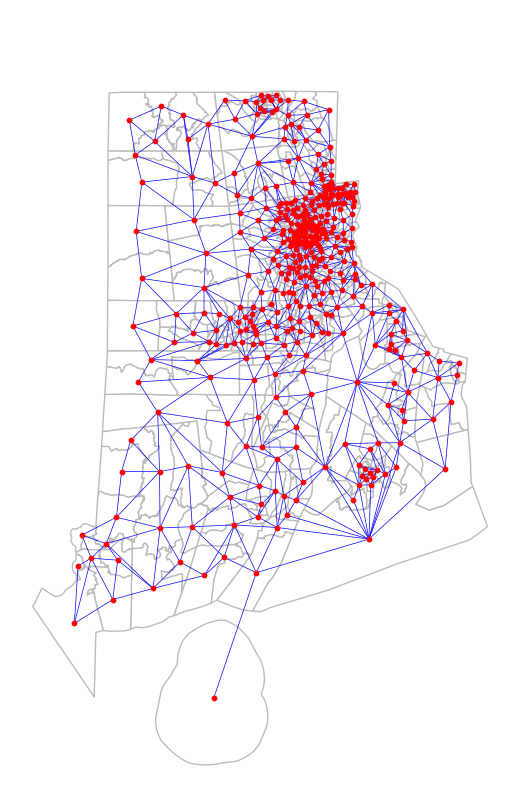

In [5]:
# Add a single edge to connect Block Island (node 91, 'New Shoreham 1') to
# its nearest mainland precinct (node 89, 'Narragansett 5').
RI_graph.add_edge(89, 91)
           
# draw the graph again to verify
fig, ax = plt.subplots(figsize=(10, 10))

RI_df.plot(ax=ax, color="white", edgecolor="#bcbcbc")

# get the centriod of each place
pos = {node: (RI_df.geometry[node].centroid.x, RI_df.geometry[node].centroid.y) for node in RI_graph.nodes}

nx.draw(RI_graph, 
        pos, 
        ax=ax, 
        node_size=10, 
        node_color="red", 
        edge_color="blue", 
        width=0.5
)

plt.title("Modified Dual Graph of Rhode Island (island edge added)")
plt.show()

In [6]:

is_contig = nx.is_connected(RI_graph)
print(f"Dual graph is connected or not: {is_contig}")

Dual graph is connected or not: True


In [7]:
# island population and its share of Rhode Island's total
island_node = 91
mainland_node = 89

island_pop = int(RI_df.iloc[island_node]["TOTPOP"])
state_pop  = int(RI_df["TOTPOP"].sum())

print(f"Island precinct (node {island_node}, {RI_df.iloc[island_node]['NAME20']}) population: {island_pop:,}")
print(f"Rhode Island statewide population (2020 Census): {state_pop:,}")
print(f"Island share of state population: {100 * island_pop / state_pop:.3f}%")
print(f"Mainland precinct it is connected to (node {mainland_node}): {RI_df.iloc[mainland_node]['NAME20']}")

Island precinct (node 91, New Shoreham 1) population: 1,410
Rhode Island statewide population (2020 Census): 1,097,379
Island share of state population: 0.128%
Mainland precinct it is connected to (node 89): Narragansett 5


### Creating at least 2 Markov Chain ensembles using ReCom 
1. Use 2020 Presidential Election (G20PREDBID (Democrat), G20PRERTRU(Republican))
2. Use 2020 U.S. Senate Election (G20USSDREE (Democrat), G20USSRWAT(Republican))

In [8]:
ri_data = gpd.read_file("./FinalShapeFiles/RI.shp")
district_summary = ri_data.groupby("SEND")["TOTPOP"].sum()

total_population = district_summary.sum()
number_of_districts = len(district_summary)

ideal_pop = total_population / number_of_districts

# VEST-precinct / census-block boundary
pop_tolerance = 0.30
rw_proposal = partial(recom, ## how you choose a next districting plan
                      pop_col = "TOTPOP", ## What data describes population
                      pop_target = ideal_pop, ## What the target/ideal population is for each district 
                                              ## (we calculated ideal pop above)
                      epsilon = pop_tolerance,  ## how far from ideal population you can deviate
                                              ## (we set pop_tolerance above)
                      node_repeats = 20, ## number of times to repeat bipartition.  Can increase if you get a BipartitionWarning
                      method=partial(
                            bipartition_tree,
                            max_attempts=1000,
                            allow_pair_reselection=True
                        )
                      )

In [9]:
# 1. 2020 Presidential Election
pres_election = Election(
    "Pres20",
    {"Dem": "PRES20D", "Rep": "PRES20R"}
)

# 2. 2020 U.S. Senate Election
senate_election = Election(
    "Sen20",
    {"Dem": "SEN20D", "Rep": "SEN20R"}
)

my_updaters = {
    "population": Tally("TOTPOP", alias="population"), 
    "cut_edges": cut_edges,
    "VAP": Tally("VAP", alias="VAP"),
    "HVAP": Tally("HVAP", alias="HVAP"),
    # "BVAP": Tally("BVAP", alias="BVAP"),
    "Pres20": pres_election,
    "Sen20": senate_election,

    # Get the efficiency gap
    "eff_gap_pres": lambda p: efficiency_gap(p["Pres20"]),
    "eff_gap_sen": lambda p: efficiency_gap(p["Sen20"])
}

initial_partition = Partition(
    RI_graph,              
    assignment="SEND",      
    updaters=my_updaters
)

### Enacted Map Reference Values (for histogram overlays)


In [10]:
# Compute enacted-map metric values from the initial partition.
enacted_cut_edges        = len(initial_partition["cut_edges"])
enacted_pres_dem_seats   = initial_partition["Pres20"].wins("Dem")
enacted_sen_dem_seats    = initial_partition["Sen20"].wins("Dem")
enacted_pres_eg          = initial_partition["eff_gap_pres"]
enacted_sen_eg           = initial_partition["eff_gap_sen"]

enacted_latino_districts = 0
for dist in initial_partition["HVAP"]:
    if initial_partition["VAP"][dist] > 0:
        if initial_partition["HVAP"][dist] / initial_partition["VAP"][dist] >= 0.5:
            enacted_latino_districts += 1

print("=== 2022 enacted RI State Senate map ===")
print(f"Cut edges:                      {enacted_cut_edges}")
print(f"Dem-won seats (Pres 2020):      {enacted_pres_dem_seats}")
print(f"Dem-won seats (U.S. Sen 2020):  {enacted_sen_dem_seats}")
print(f"Efficiency Gap (Pres 2020):     {enacted_pres_eg:.4f}")
print(f"Efficiency Gap (U.S. Sen 2020): {enacted_sen_eg:.4f}")
print(f"Latino-majority districts:      {enacted_latino_districts}")

=== 2022 enacted RI State Senate map ===
Cut edges:                      498
Dem-won seats (Pres 2020):      33
Dem-won seats (U.S. Sen 2020):  37
Efficiency Gap (Pres 2020):     0.1391
Efficiency Gap (U.S. Sen 2020): 0.1367
Latino-majority districts:      3


Evidence of convergence (that you have run the chain long enough)

In [11]:

population_constraint = constraints.within_percent_of_ideal_population(
    initial_partition,
    pop_tolerance
)

our_random_walk = MarkovChain(
    proposal = rw_proposal, 
    constraints = [population_constraint], # Could add additional constraints here
    accept = always_accept, # Accept every proposed plan that meets the population constraints
    initial_state = initial_partition, 
    total_steps = 40000)  

rows = []

with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    for part in our_random_walk:
        num_lat_majority = 0
        for dist in part["HVAP"]:
            if part["VAP"][dist] > 0:
                hvap_share = part["HVAP"][dist] / part["VAP"][dist]
                if hvap_share >= 0.5:
                    num_lat_majority += 1

        rows.append({
            "pres_dem_seats":   part["Pres20"].wins("Dem"),
            "sen_dem_seats":    part["Sen20"].wins("Dem"),
            "cut_edges":        len(part["cut_edges"]),
            "pres_eg":          part["eff_gap_pres"],
            "sen_eg":           part["eff_gap_sen"],
            "latino_districts": num_lat_majority,
        })

ensemble_df = pd.DataFrame(rows)
ensemble_df.to_csv("ensemble_results.csv", index=False)

# expose the ensemble columns as lists so the histogram cell below
pres_dem_seats            = ensemble_df["pres_dem_seats"].tolist()
sen_dem_seats             = ensemble_df["sen_dem_seats"].tolist()
cutedge_ensemble          = ensemble_df["cut_edges"].tolist()
pres_eg_scores            = ensemble_df["pres_eg"].tolist()
sen_eg_scores             = ensemble_df["sen_eg"].tolist()
latino_districts_ensemble = ensemble_df["latino_districts"].tolist()

print(f"Saved ensemble_results.csv with {len(ensemble_df):,} rows.")
ensemble_df.head()


Saved ensemble_results.csv with 40,000 rows.


,pres_dem_seats,sen_dem_seats,cut_edges,pres_eg,sen_eg,latino_districts
0,33,37,498,0.139083,0.13672,3
1,33,37,496,0.139083,0.13672,3
2,33,37,496,0.139083,0.13672,3
3,33,37,498,0.139083,0.13672,3
4,33,37,494,0.139083,0.13672,3


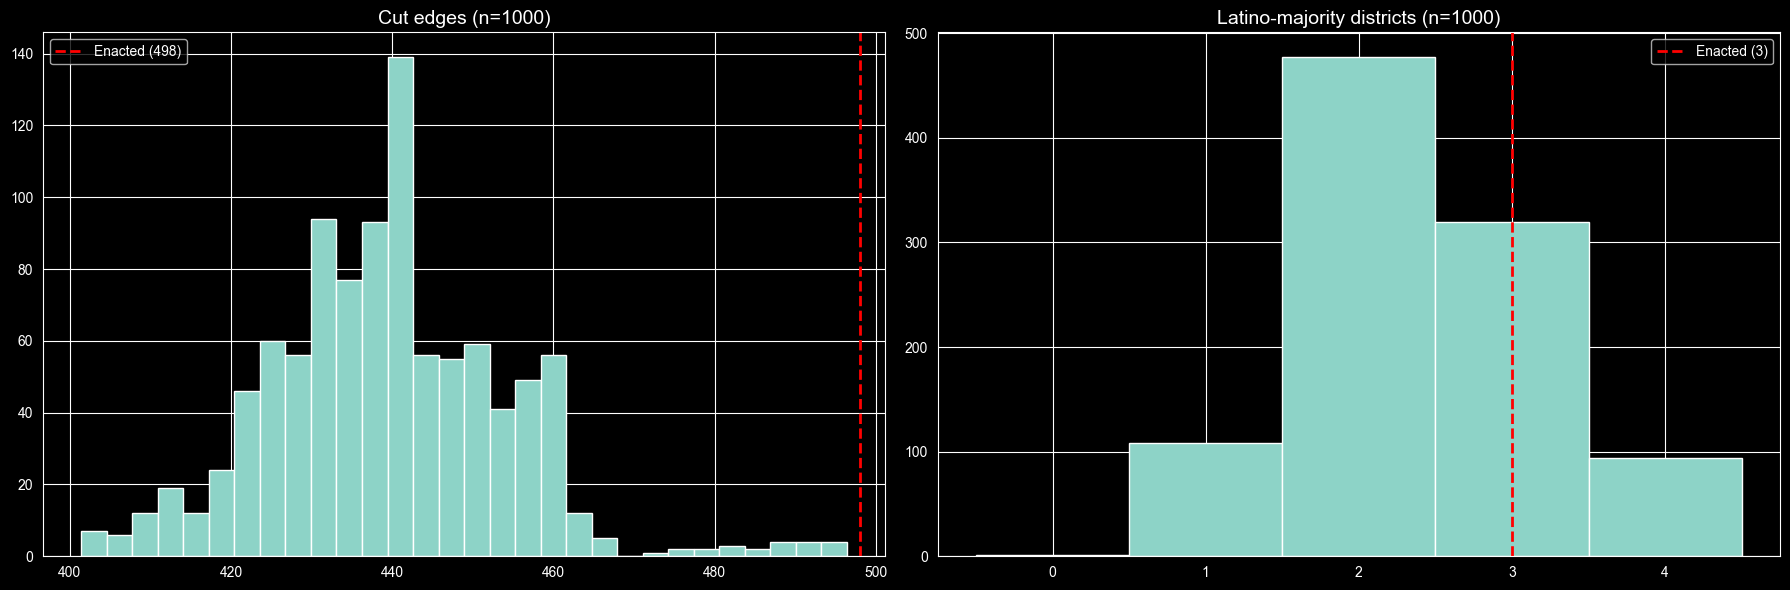

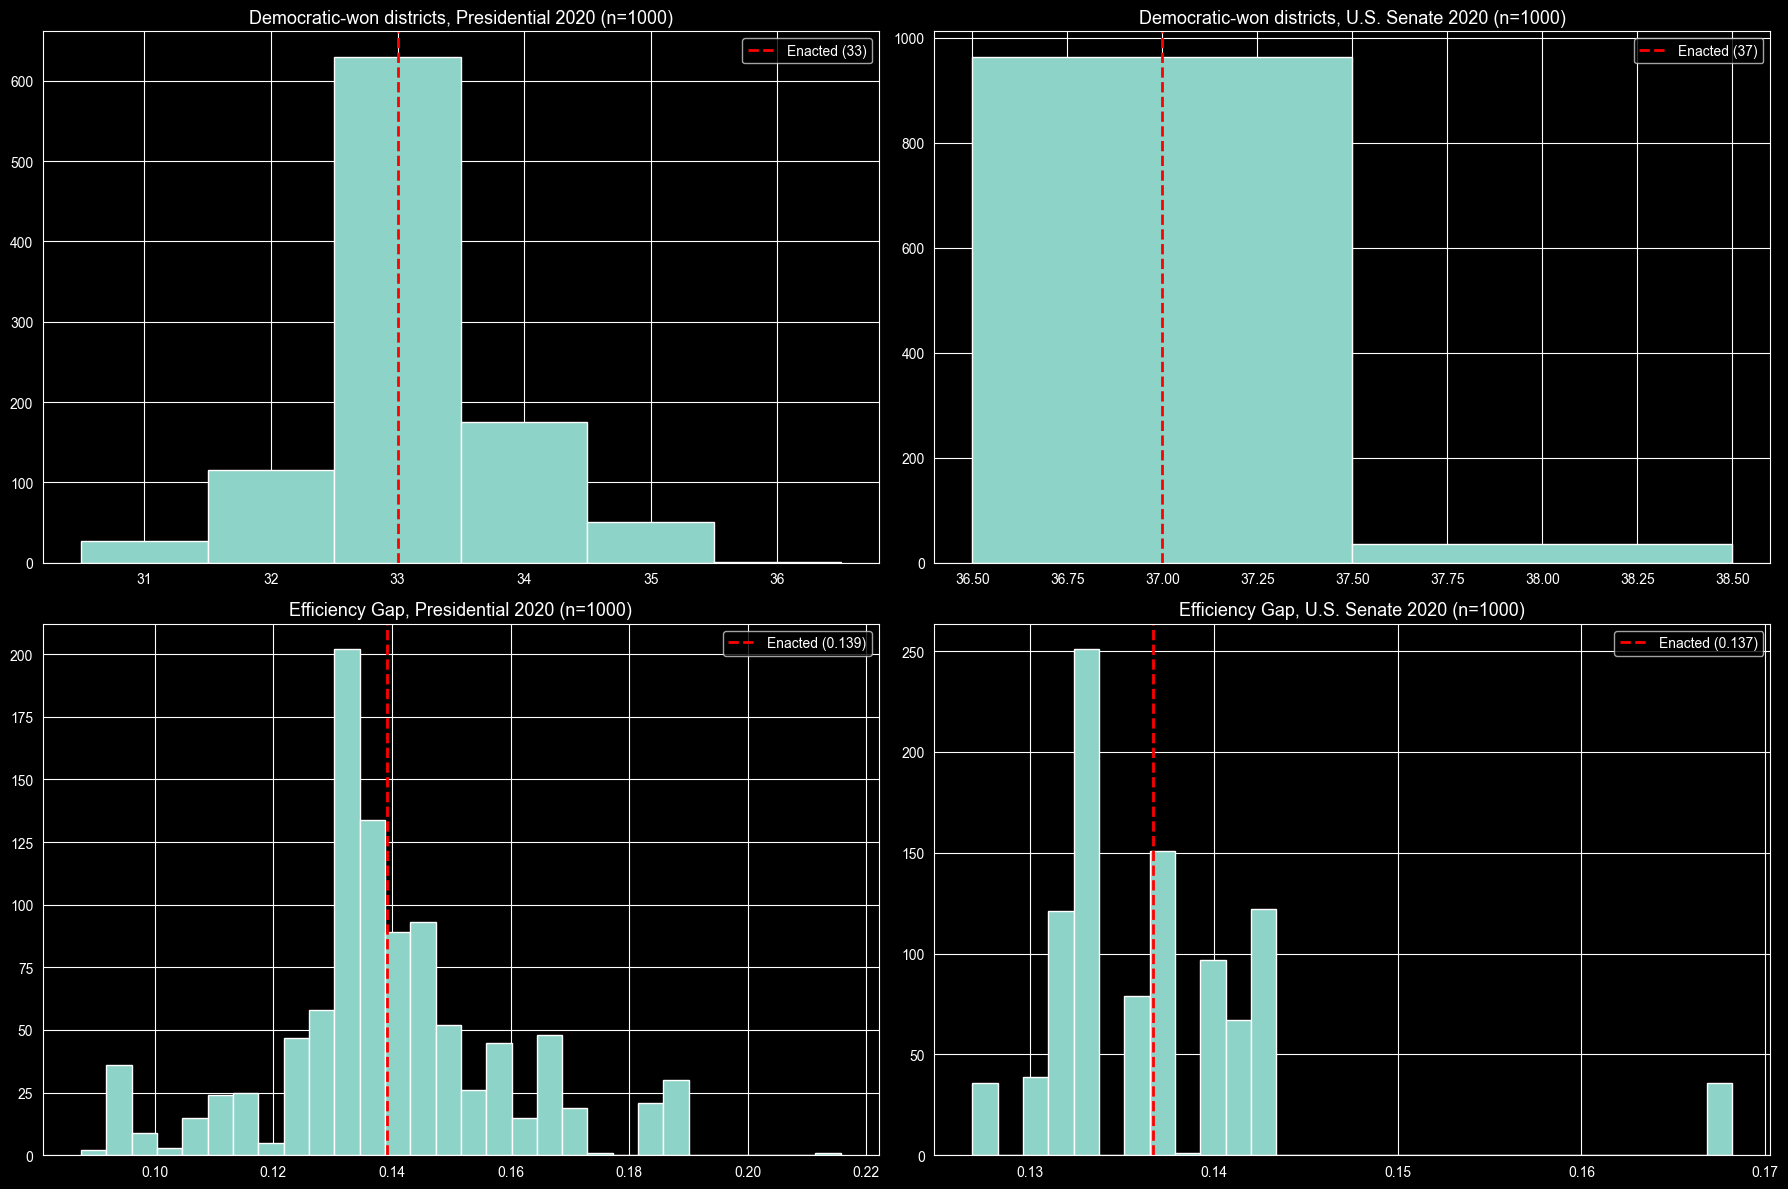

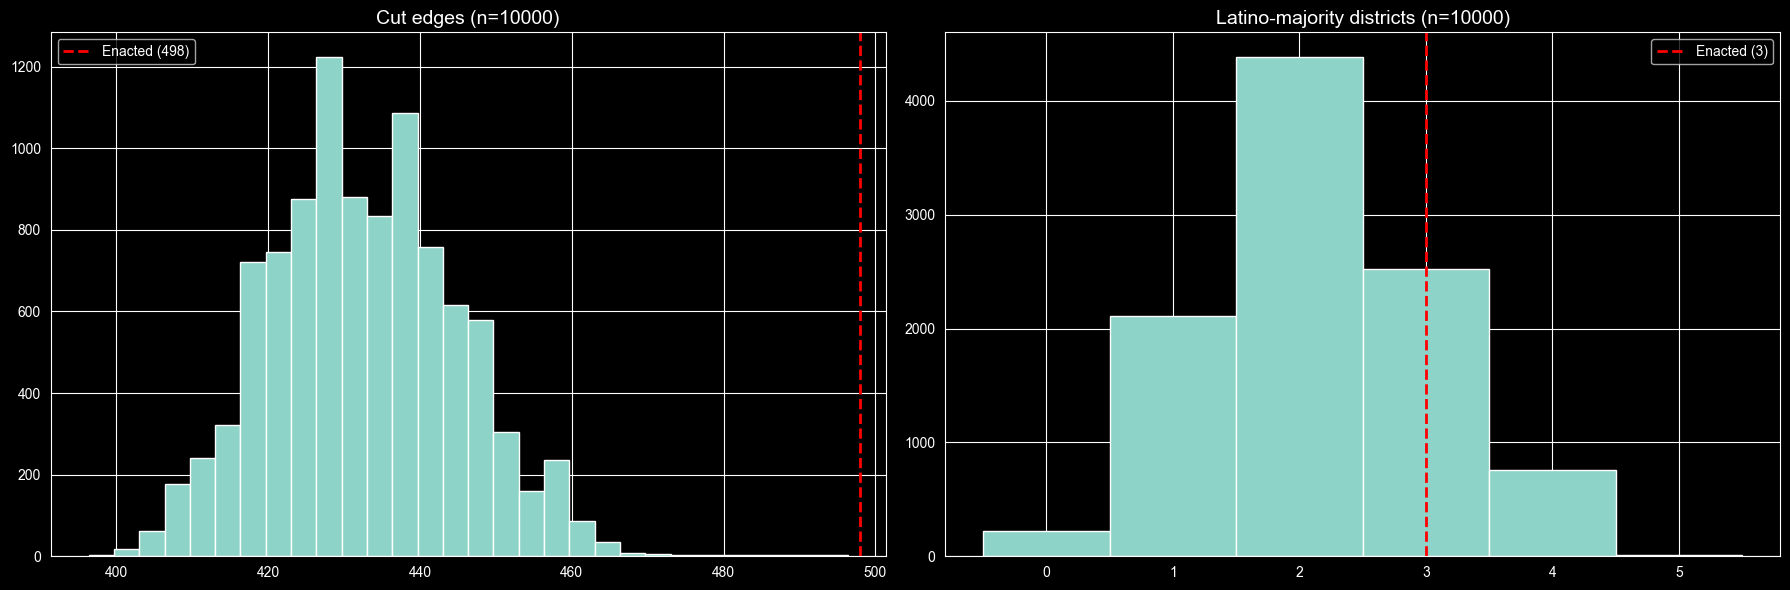

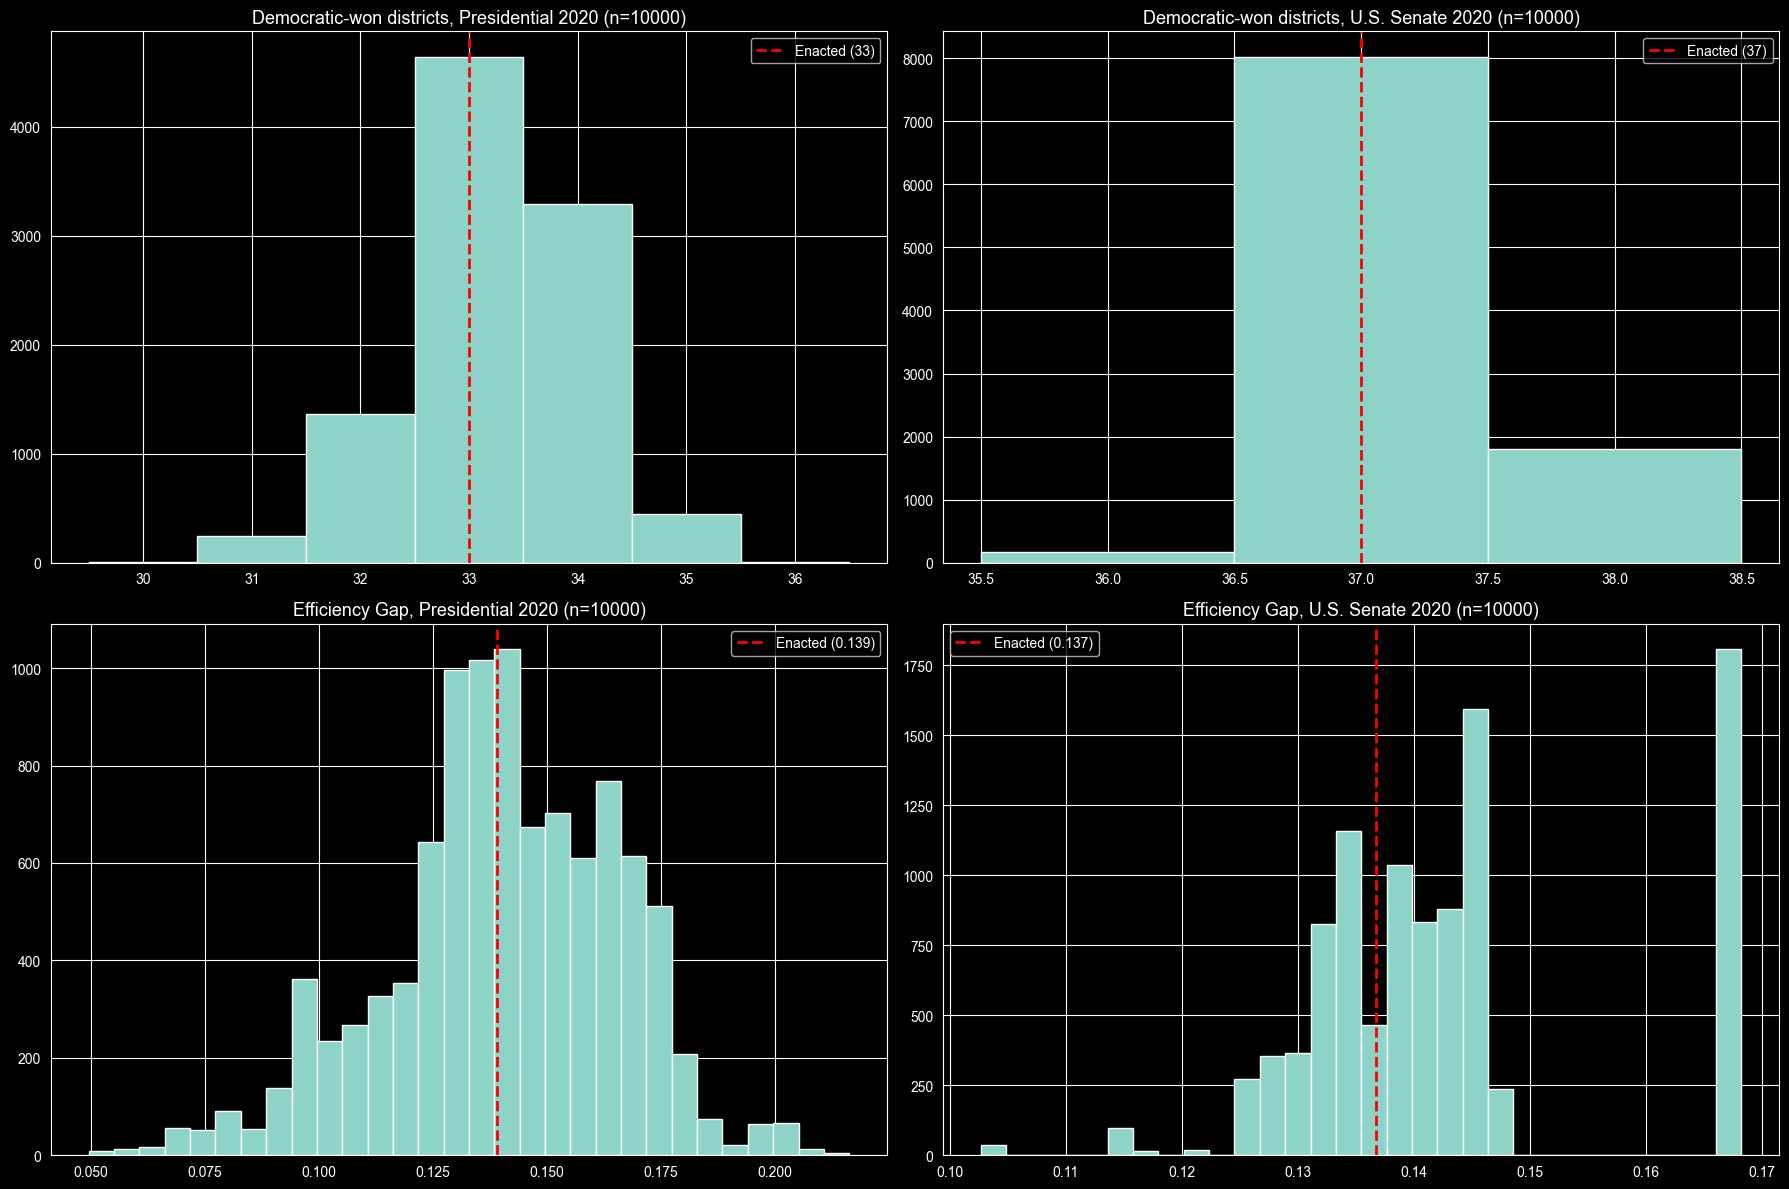

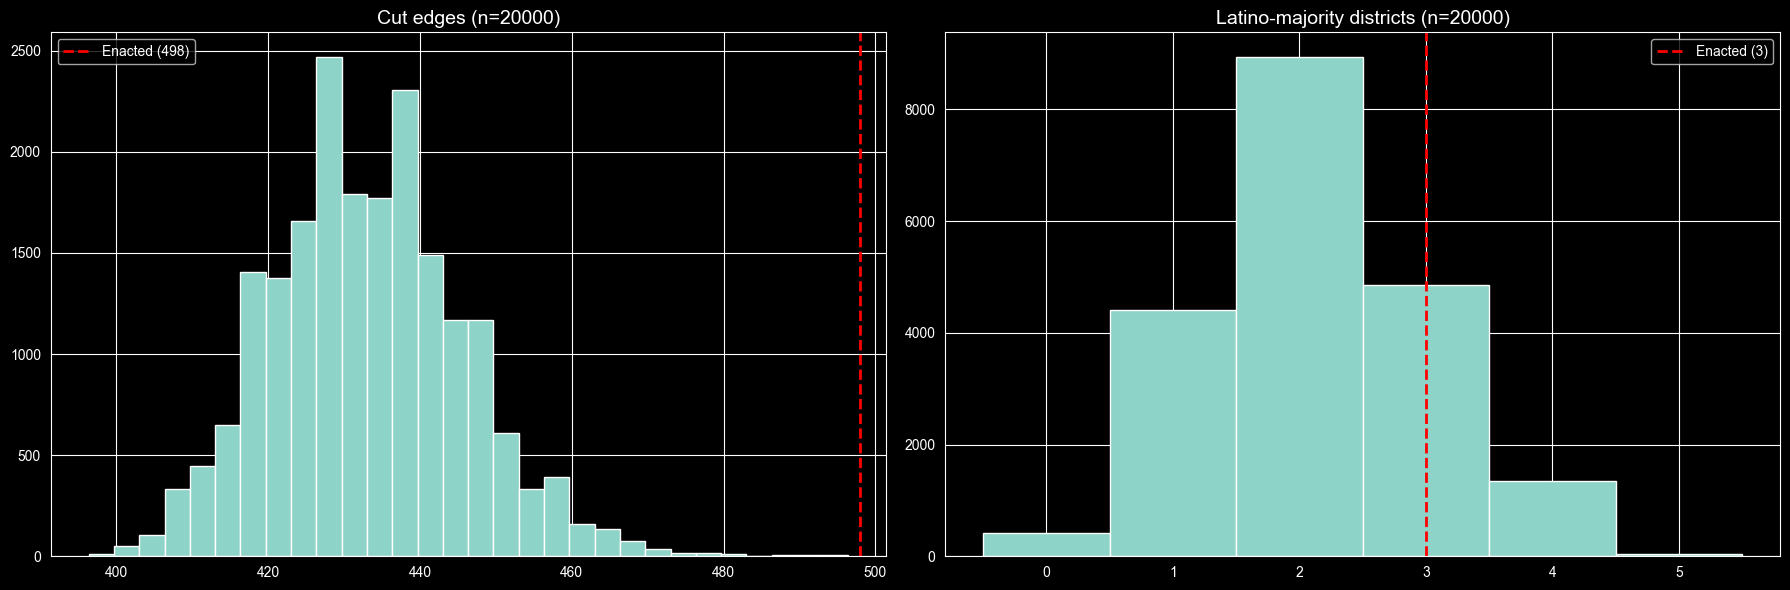

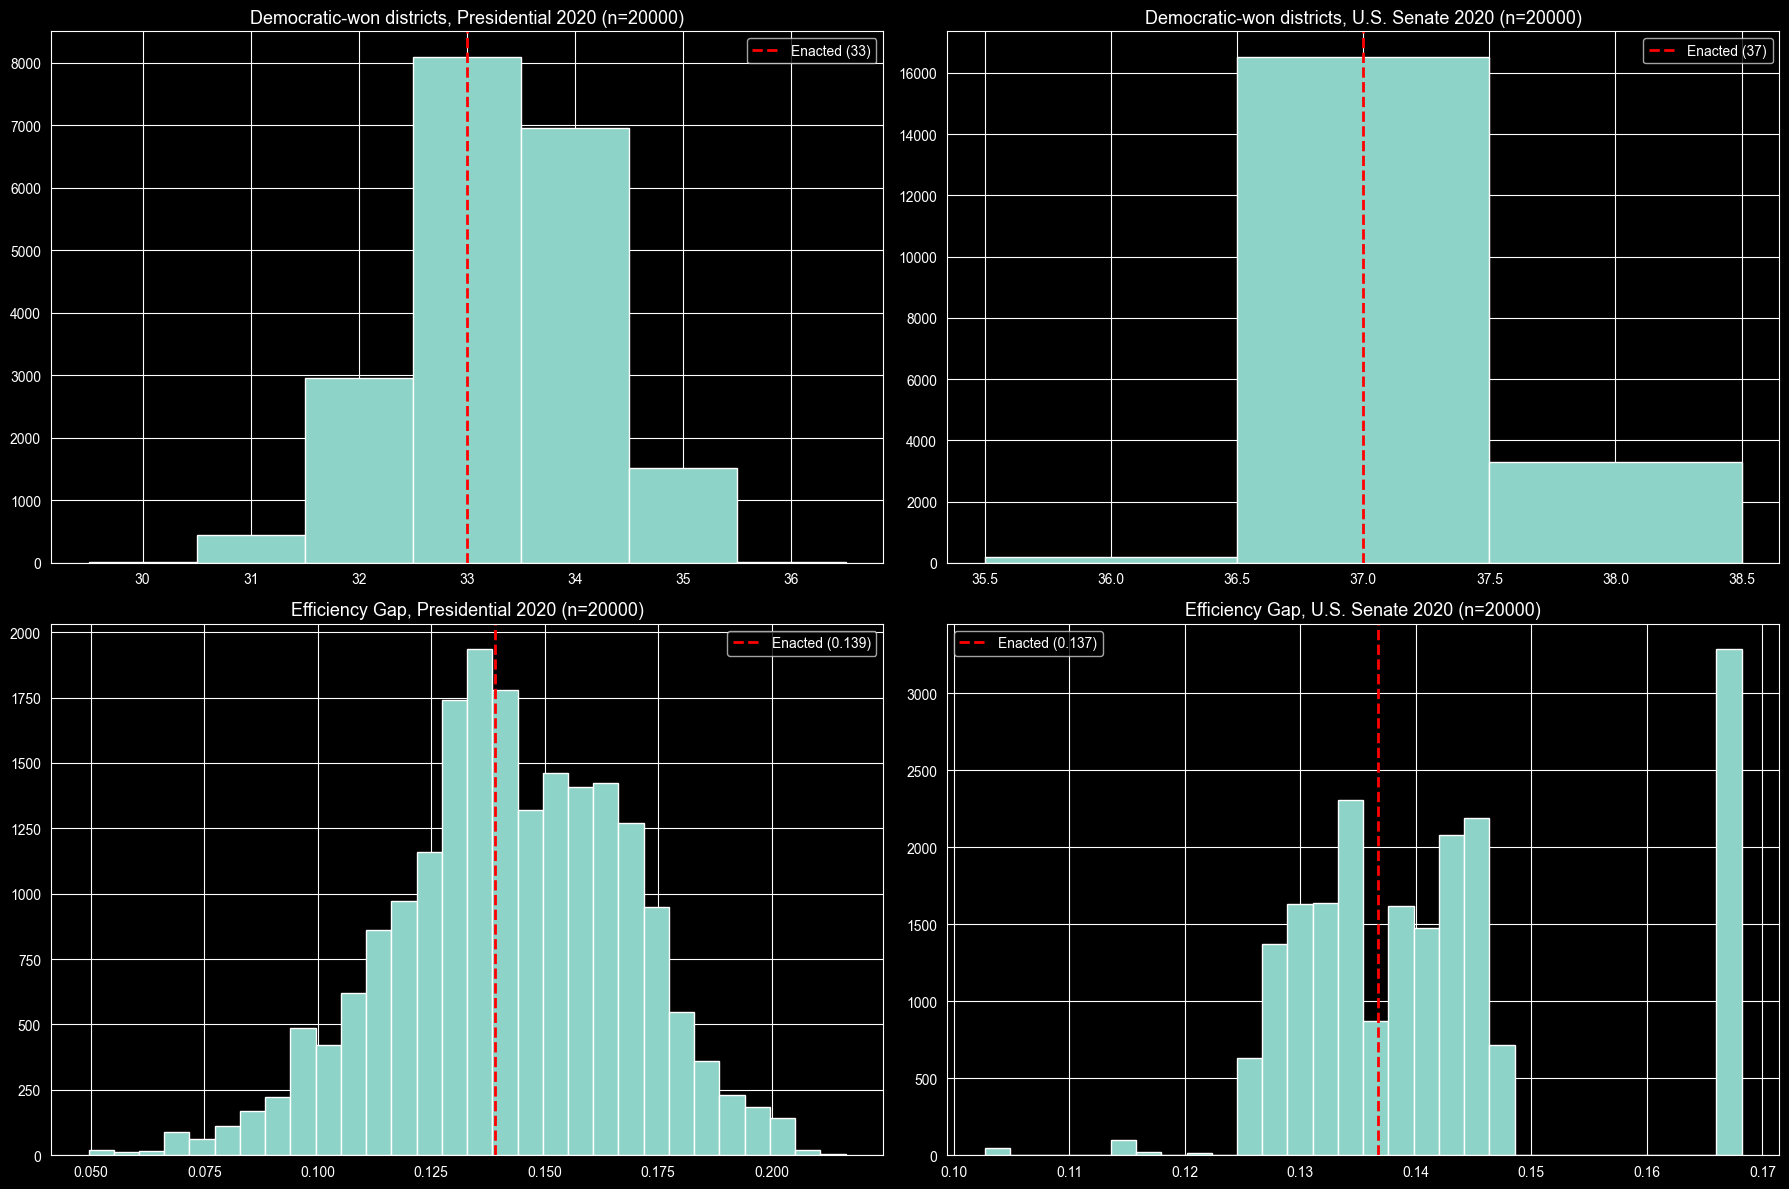

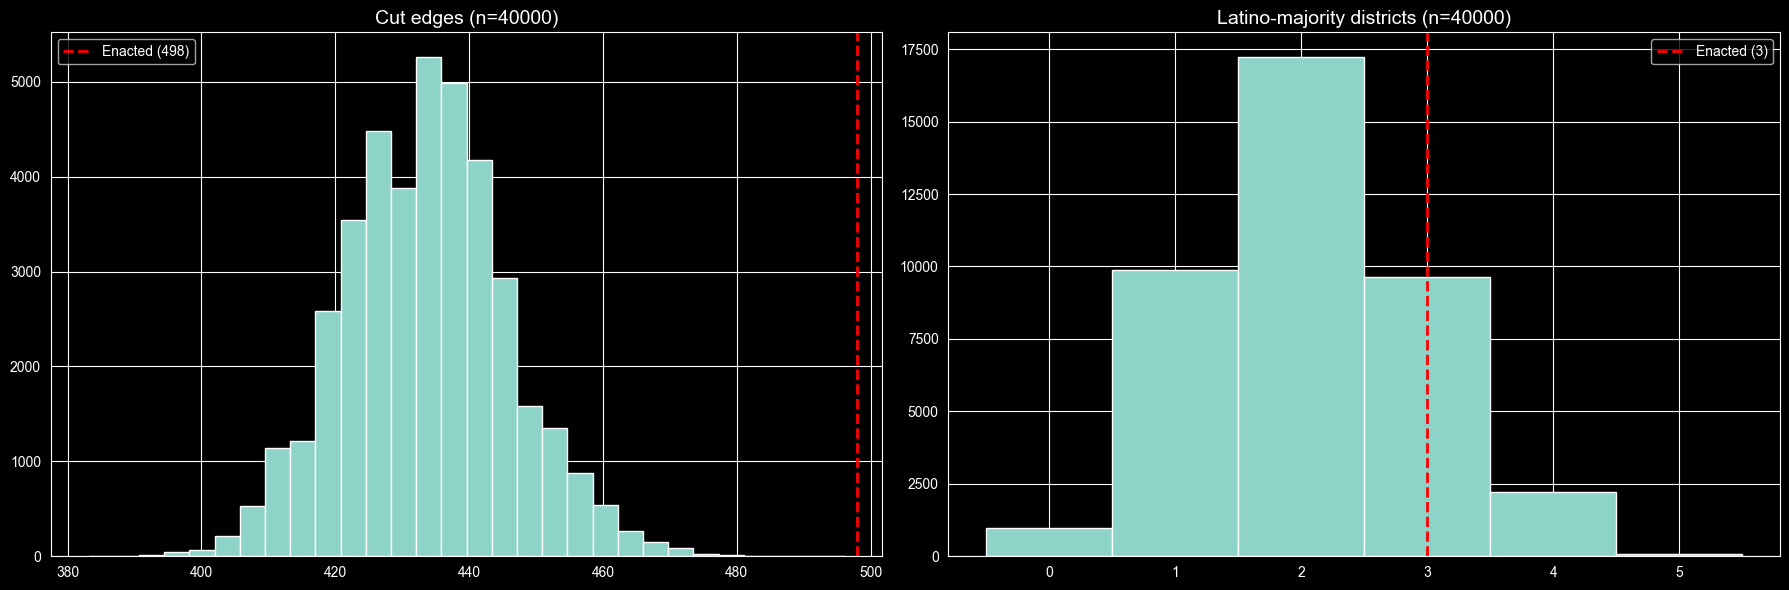

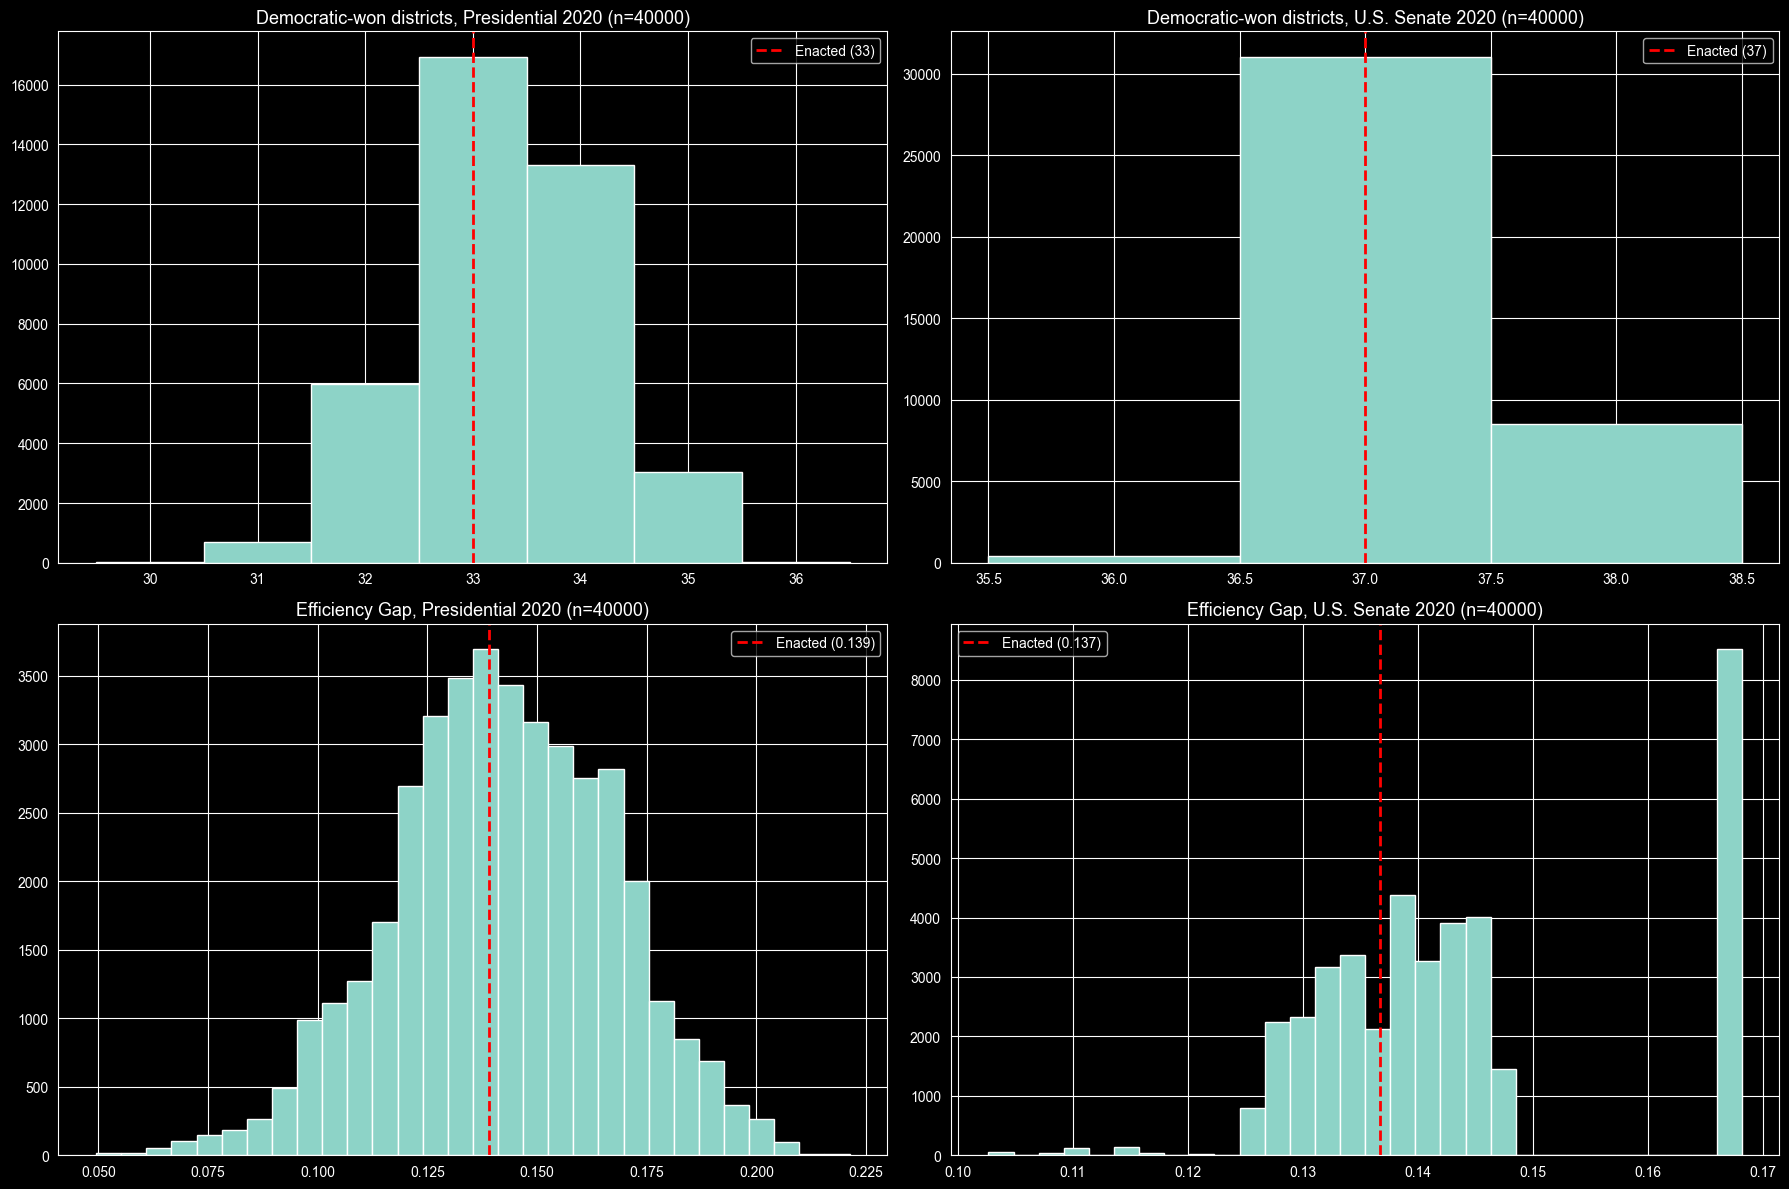

In [12]:
# Histograms with enacted-map reference line
# Each subplot shows the ensemble distribution; the red dashed line marks
# the value from the 2022 enacted RI Senate map

for size in [1000, 10000, 20000, 40000]:
    fig, axes = plt.subplots(1, 2, figsize=(18, 6))

    axes[0].hist(cutedge_ensemble[:size], bins=30, align='left')
    axes[0].axvline(enacted_cut_edges, color='red', linestyle='--', linewidth=2,  label=f'Enacted ({enacted_cut_edges})')
    axes[0].set_title(f"Cut edges (n={size})", fontsize=14)
    axes[0].legend()

    axes[1].hist(latino_districts_ensemble[:size], bins=range(0, max(latino_districts_ensemble[:size]) + 2), align='left')
    axes[1].axvline(enacted_latino_districts, color='red', linestyle='--', linewidth=2, label=f'Enacted ({enacted_latino_districts})')
    axes[1].set_title(f"Latino-majority districts (n={size})", fontsize=14)
    axes[1].legend()

    plt.tight_layout()
    plt.show()

    fig, axes = plt.subplots(2, 2, figsize=(18, 12))

    axes[0][0].hist(pres_dem_seats[:size], bins=range(min(pres_dem_seats[:size]), max(pres_dem_seats[:size]) + 2), align='left')
    axes[0][0].axvline(enacted_pres_dem_seats, color='red', linestyle='--', linewidth=2,label=f'Enacted ({enacted_pres_dem_seats})')
    axes[0][0].set_title(f"Democratic-won districts, Presidential 2020 (n={size})", fontsize=13)
    axes[0][0].legend()

    axes[0][1].hist(sen_dem_seats[:size], bins=range(min(sen_dem_seats[:size]), max(sen_dem_seats[:size]) + 2), align='left')
    axes[0][1].axvline(enacted_sen_dem_seats, color='red', linestyle='--', linewidth=2,label=f'Enacted ({enacted_sen_dem_seats})')
    axes[0][1].set_title(f"Democratic-won districts, U.S. Senate 2020 (n={size})", fontsize=13)
    axes[0][1].legend()

    axes[1][0].hist(pres_eg_scores[:size], bins=30)
    axes[1][0].axvline(enacted_pres_eg, color='red', linestyle='--', linewidth=2,  label=f'Enacted ({enacted_pres_eg:.3f})')
    axes[1][0].set_title(f"Efficiency Gap, Presidential 2020 (n={size})", fontsize=13)
    axes[1][0].legend()

    axes[1][1].hist(sen_eg_scores[:size], bins=30)
    axes[1][1].axvline(enacted_sen_eg, color='red', linestyle='--', linewidth=2,label=f'Enacted ({enacted_sen_eg:.3f})')
    axes[1][1].set_title(f"Efficiency Gap, U.S. Senate 2020 (n={size})", fontsize=13)
    axes[1][1].legend()

    plt.tight_layout()
    plt.show()

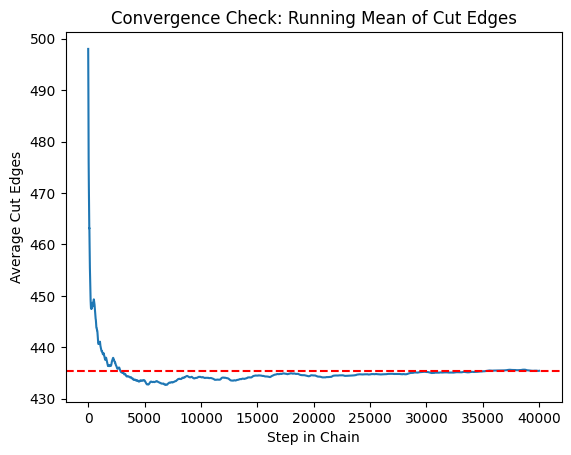

In [1]:
# Plot running mean to show the chain has run long enough
import pandas as pd
import matplotlib.pyplot as plt
ensemble_df = pd.read_csv("ensemble_results.csv") 

running_mean = ensemble_df["cut_edges"].expanding().mean()
plt.plot(running_mean)
plt.axhline(y=running_mean.iloc[-1], color='r', linestyle='--')
plt.title("Convergence Check: Running Mean of Cut Edges")
plt.xlabel("Step in Chain")
plt.ylabel("Average Cut Edges")
plt.show()


Marginal box plots (sometimes called the “signature of gerrymandering”)

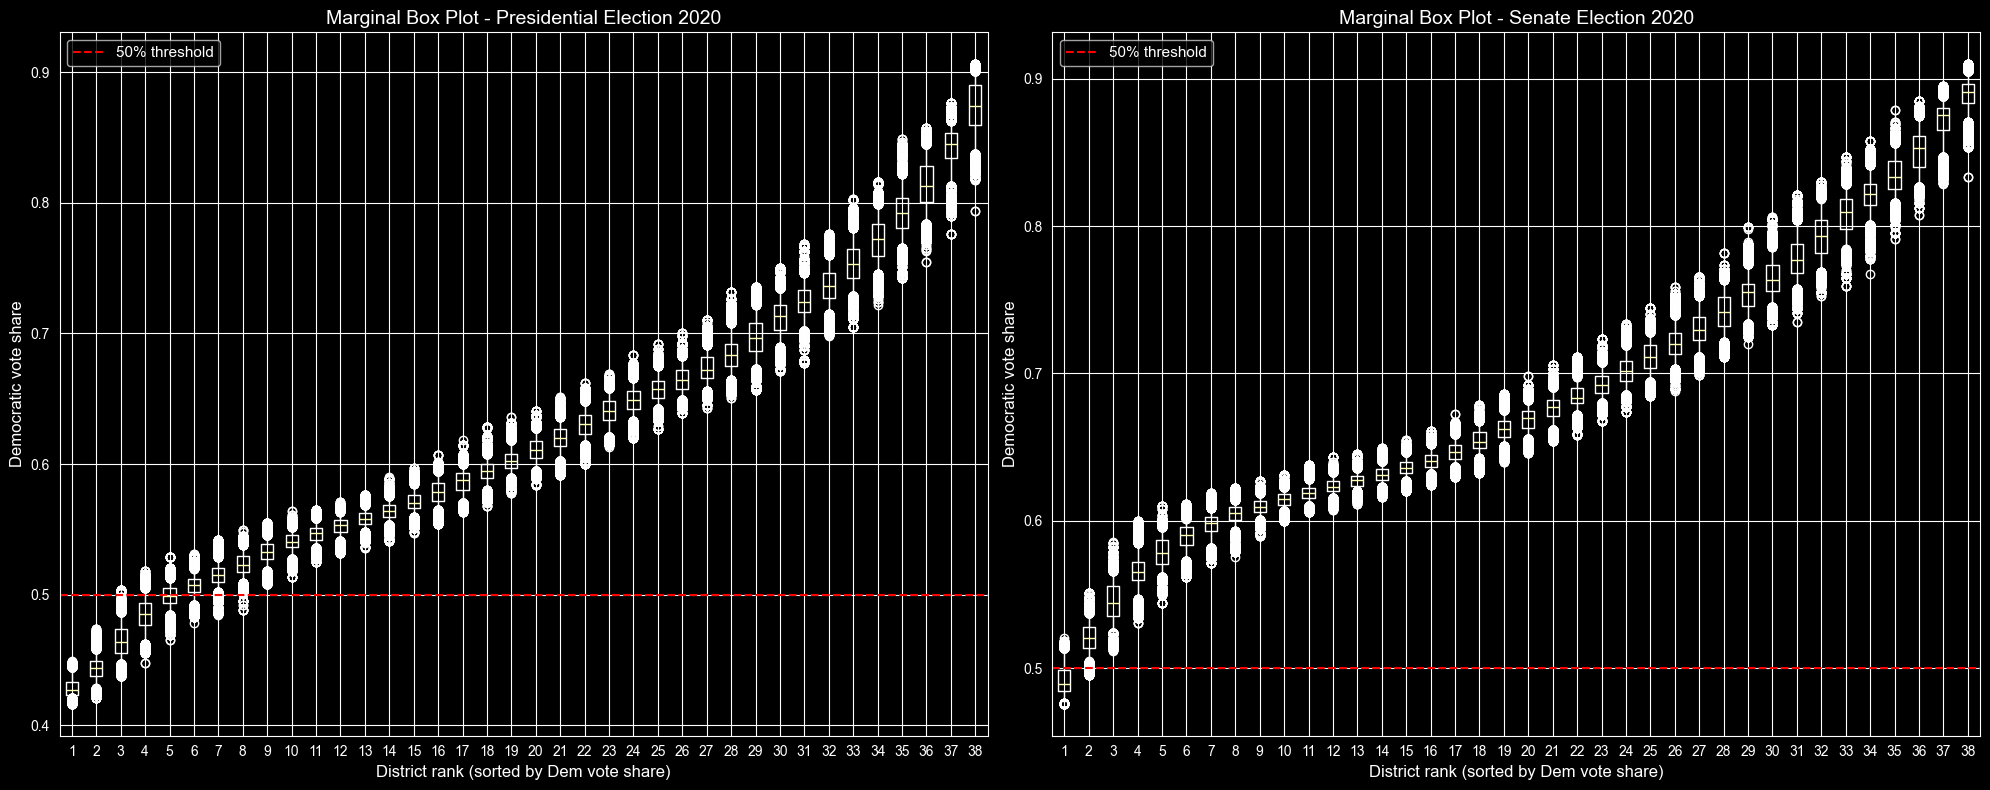

In [13]:
# Marginal box plots - "signature of gerrymandering"
# Each box shows the distribution of Dem vote share for one district rank
# across all steps in the ensemble.
pres_district_shares = []
sen_district_shares  = []

boxplot_walk = MarkovChain(
    proposal=rw_proposal,
    constraints=[population_constraint],
    accept=always_accept,
    initial_state=initial_partition,
    total_steps=10000
)

for part in boxplot_walk:
    pres_results = part["Pres20"]
    sen_results  = part["Sen20"]

    pres_shares = sorted(pres_results.percents("Dem"))
    sen_shares  = sorted(sen_results.percents("Dem"))

    pres_district_shares.append(pres_shares)
    sen_district_shares.append(sen_shares)

# Transpose: each element = all values for one district rank across chain steps
pres_by_rank = list(zip(*pres_district_shares))
sen_by_rank  = list(zip(*sen_district_shares))

num_districts = len(pres_by_rank)

fig, axes = plt.subplots(1, 2, figsize=(20, 8))

# Presidential
axes[0].boxplot(pres_by_rank, positions=range(1, num_districts + 1), whis=[5, 95])
axes[0].axhline(0.5, color='red', linestyle='--', linewidth=1.5, label='50% threshold')
axes[0].set_xlabel("District rank (sorted by Dem vote share)", fontsize=12)
axes[0].set_ylabel("Democratic vote share", fontsize=12)
axes[0].set_title("Marginal Box Plot - Presidential Election 2020", fontsize=14)
axes[0].legend(fontsize=11)

# Senate
axes[1].boxplot(sen_by_rank, positions=range(1, num_districts + 1), whis=[5, 95])
axes[1].axhline(0.5, color='red', linestyle='--', linewidth=1.5, label='50% threshold')
axes[1].set_xlabel("District rank (sorted by Dem vote share)", fontsize=12)
axes[1].set_ylabel("Democratic vote share", fontsize=12)
axes[1].set_title("Marginal Box Plot - Senate Election 2020", fontsize=14)
axes[1].legend(fontsize=11)

plt.tight_layout()
plt.show()